## SVM

###Baseline SVM

MSE: 7.856133695532871
MAE: 1.3801324367344108
R2: 0.8089141041079069


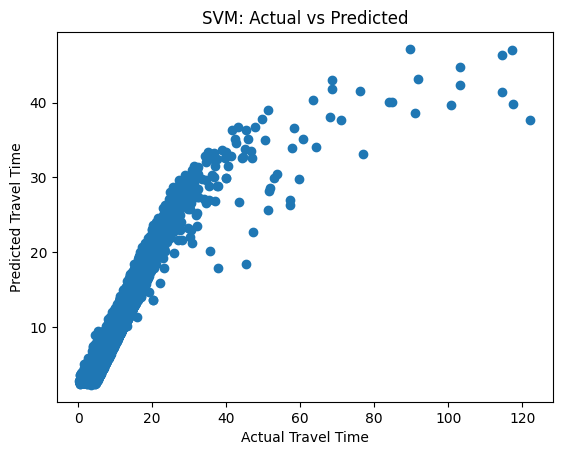

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

url = "https://raw.githubusercontent.com/lwenqing090-web/traffic-signal-ml-project/refs/heads/main/data/cleansed_traffic_monitoring.csv"
df = pd.read_csv(url)

# selected features
features = [
    'Traffic_Speed',
    'Road_Length',
    'Traffic_Volume',
    'Traffic_Density',
    'Signal_Phase_Duration',
    'Time_of_Day'
]
X = df[features]
y = df['Travel_Time']

# train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42)

#Feature scaling for SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Support Vector Regression
svr_model = SVR(kernel='rbf')
svr_model.fit(X_train_scaled, y_train)

#Prediction
y_pred = svr_model.predict(X_test_scaled)

#Model evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("MAE:", mae)
print("R2:", r2)

#Scatter plot
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Travel Time")
plt.ylabel("Predicted Travel Time")
plt.title("Baseline SVM: Actual vs Predicted")
plt.show()

### Hyperparameter Tuning

In [2]:
param_grid = {
    'C': [1, 10, 50],
    'epsilon': [0.1, 0.5, 1],
    'gamma': ['scale', 0.1, 0.01]
}

grid = GridSearchCV(
    SVR(kernel='rbf'),
    param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    verbose=2
)

grid.fit(X_train_scaled, y_train)

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test_scaled)

Fitting 3 folds for each of 27 candidates, totalling 81 fits
[CV] END ......................C=1, epsilon=0.1, gamma=scale; total time= 1.2min
[CV] END ......................C=1, epsilon=0.1, gamma=scale; total time= 1.2min
[CV] END ......................C=1, epsilon=0.1, gamma=scale; total time= 1.2min
[CV] END ........................C=1, epsilon=0.1, gamma=0.1; total time= 1.5min
[CV] END ........................C=1, epsilon=0.1, gamma=0.1; total time= 1.2min
[CV] END ........................C=1, epsilon=0.1, gamma=0.1; total time= 1.2min
[CV] END .......................C=1, epsilon=0.1, gamma=0.01; total time= 1.2min
[CV] END .......................C=1, epsilon=0.1, gamma=0.01; total time= 1.2min
[CV] END .......................C=1, epsilon=0.1, gamma=0.01; total time= 1.2min
[CV] END ......................C=1, epsilon=0.5, gamma=scale; total time= 1.0min
[CV] END ......................C=1, epsilon=0.5, gamma=scale; total time= 1.0min
[CV] END ......................C=1, epsilon=0.5,

### Tuned SVM (Best Hyperparameters)

In [16]:
#Best parameter
import numpy as np
gamma_value = 1 / (X_train_scaled.shape[1] * np.var(X_train_scaled))
print("Best parameters:", grid.best_params_)
print("Approximate gamma value (scale):", gamma_value)

Best parameters: {'C': 50, 'epsilon': 1, 'gamma': 'scale'}
Approximate gamma value (scale): 0.16666666666666666


In [15]:
# Evaluation metrics for the best SVM model
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Tuned SVM Results:")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R2: {r2:.4f}")

Tuned SVM Results:
MSE: 3.4884
MAE: 1.2849
R2: 0.9152


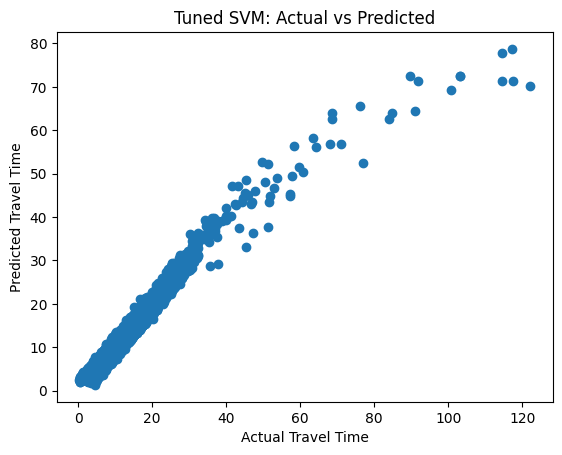

In [13]:
#Scatter plot for the best SVM model
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Travel Time")
plt.ylabel("Predicted Travel Time")
plt.title("Tuned SVM: Actual vs Predicted")

plt.show()